# Imports Libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import joblib
import warnings
warnings.filterwarnings("ignore")

# LOAD AND MERGE ALL DATA

In [2]:
cleveland = pd.read_csv("data/processed/cleveland_clean.csv")
hungarian = pd.read_csv("data/processed/hungarian_clean.csv")
switzerland = pd.read_csv("data/processed/switzerland_clean.csv")
va = pd.read_csv("data/processed/va_clean.csv")

print("Load All Cleaned Datasets")

Load All Cleaned Datasets


In [3]:
df = pd.concat(
    [cleveland, hungarian, switzerland, va],
    ignore_index=True
)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(920, 14)


# Features & Target

In [5]:
x = df.drop("target", axis=1)
y = df["target"]

# Train/Test Split

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x ,y,test_size=0.20,
                                                    random_state=42, stratify=y)

print(x_train.shape)
print(x_test.shape)

(736, 13)
(184, 13)


In [7]:
df["target"].value_counts()

target
1    509
0    411
Name: count, dtype: int64

## Logistic Regression

In [9]:
lr_pipeline = Pipeline([
     ('imputer', SimpleImputer(strategy='median')),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced"))
])

In [10]:
lr_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
    "model__max_iter": [1000]
}

In [12]:
lr_search = RandomizedSearchCV(
    lr_pipeline,
    lr_params,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

lr_search.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': [0.01, 0.1, ...], 'model__max_iter': [1000], 'model__solver': ['liblinear', 'lbfgs']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` d

In [13]:
best_lr = lr_search.best_estimator_
lr_search.best_params_

{'model__solver': 'liblinear', 'model__max_iter': 1000, 'model__C': 1}

# Random Forest

In [15]:
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

In [16]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

In [17]:
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [18]:
rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(x_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ve

In [19]:
best_rf = rf_search.best_estimator_
rf_search.best_params_

{'n_estimators': 100,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_depth': 5}

# XGBoost

In [26]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    ))
])

In [27]:
# xgb_params = {
#     "n_estimators": [100, 200, 300, 500, 700, 1000, 1500],
#     "max_depth": [3, 4, 5, 6],
#     "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.1],
#     "subsample": [0.7, 0.8, 0.9, 1.0],
#     "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
#     "gamma": [0, 0.1, 0.3, 0.5],
#     "min_child_weight": [3, 5, 7],
#     "reg_alpha": [0, 0.1, 0.5],
#     "reg_lambda": [1, 1.5, 2]
# }

xgb_params = {
    "model__n_estimators": [100, 200, 300, 500, 700, 1000, 1500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__gamma": [0, 0.1, 0.3, 0.5],
    "model__min_child_weight": [3, 5, 7],
    "model__reg_alpha": [0, 0.1, 0.5],
    "model__reg_lambda": [1, 1.5, 2]
}

In [28]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=80,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.02, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",80
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strate

In [29]:
best_xgb = xgb_search.best_estimator_
xgb_search.best_params_

{'model__subsample': 1.0,
 'model__reg_lambda': 1.5,
 'model__reg_alpha': 0,
 'model__n_estimators': 300,
 'model__min_child_weight': 5,
 'model__max_depth': 3,
 'model__learning_rate': 0.02,
 'model__gamma': 0.3,
 'model__colsample_bytree': 0.9}

# Evaluation Function

In [30]:
def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

    return results

In [31]:
results = []

# --- Logistic Regression ---
results.append(
    evaluate_model(
        best_lr,
        x_train,
        y_train,
        "Logistic Regression (Train)"
    )
)
results.append(
    evaluate_model(
        best_lr,
        x_test,
        y_test,
        "Logistic Regression (Test)"
    )
)

# --- Random Forest ---
results.append(
    evaluate_model(
        best_rf,
        x_train,
        y_train,
        "Random Forest (Train)"
    )
)
results.append(
    evaluate_model(
        best_rf,
        x_test,
        y_test,
        "Random Forest (Test)"
    )
)

# --- XGBoost ---
results.append(
    evaluate_model(
        best_xgb,
        x_train,
        y_train,
        "XGBoost (Train)"
    )
)
results.append(
    evaluate_model(
        best_xgb,
        x_test,
        y_test,
        "XGBoost (Test)"
    )
)

In [32]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,XGBoost (Train),0.864130,0.894602,0.855037,0.874372,0.936745
2,Random Forest (Train),0.858696,0.872236,0.872236,0.872236,0.935763
3,Random Forest (Test),0.826087,0.850000,0.833333,0.841584,0.930536
5,XGBoost (Test),0.847826,0.885417,0.833333,0.858586,0.928384
1,Logistic Regression (Test),0.842391,0.892473,0.813725,0.851282,0.905428
0,Logistic Regression (Train),0.823370,0.850633,0.825553,0.837905,0.902355


In [33]:
results_df = pd.DataFrame(results)

# 1. Extract the clean model name without "(Train)" or "(Test)"
results_df['Model_Base'] = results_df['Model'].str.replace(' (Train)', '', regex=False).str.replace(' (Test)', '', regex=False)

# 2. Extract whether it's Train or Test
results_df['Set'] = results_df['Model'].apply(lambda x: 'Train' if 'Train' in x else 'Test')

# 3. Sort so that the best TEST performing models rise to the top, 
# but their corresponding Train rows stay glued to them.
results_df = results_df.sort_values(
    by=["Model", "Set"], 
    ascending=[False, True]
).drop(columns=['Model_Base', 'Set']) # Clean up temp columns

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,XGBoost (Train),0.864130,0.894602,0.855037,0.874372,0.936745
5,XGBoost (Test),0.847826,0.885417,0.833333,0.858586,0.928384
2,Random Forest (Train),0.858696,0.872236,0.872236,0.872236,0.935763
3,Random Forest (Test),0.826087,0.850000,0.833333,0.841584,0.930536
0,Logistic Regression (Train),0.823370,0.850633,0.825553,0.837905,0.902355
1,Logistic Regression (Test),0.842391,0.892473,0.813725,0.851282,0.905428


# Visualization

In [35]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_curve,
    auc
)

In [36]:
best_model = best_xgb   

y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:, 1]

In [37]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.87      0.84        82
           1       0.89      0.83      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



# Confusion Matrix

In [38]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[71 11]
 [17 85]]


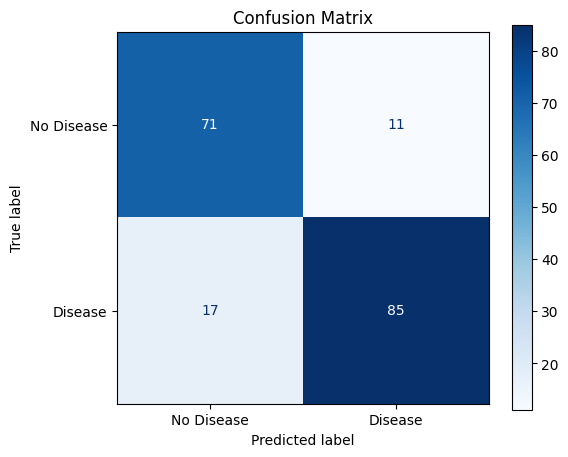

In [39]:
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
).plot(
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix")
plt.show()

In [40]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

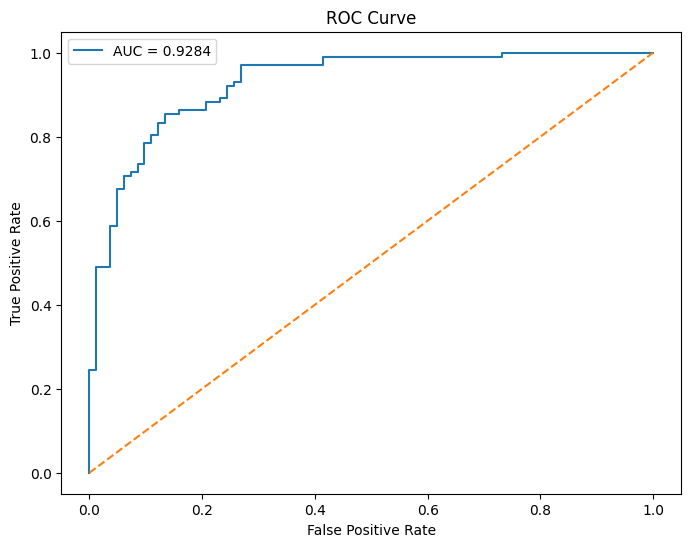

In [41]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

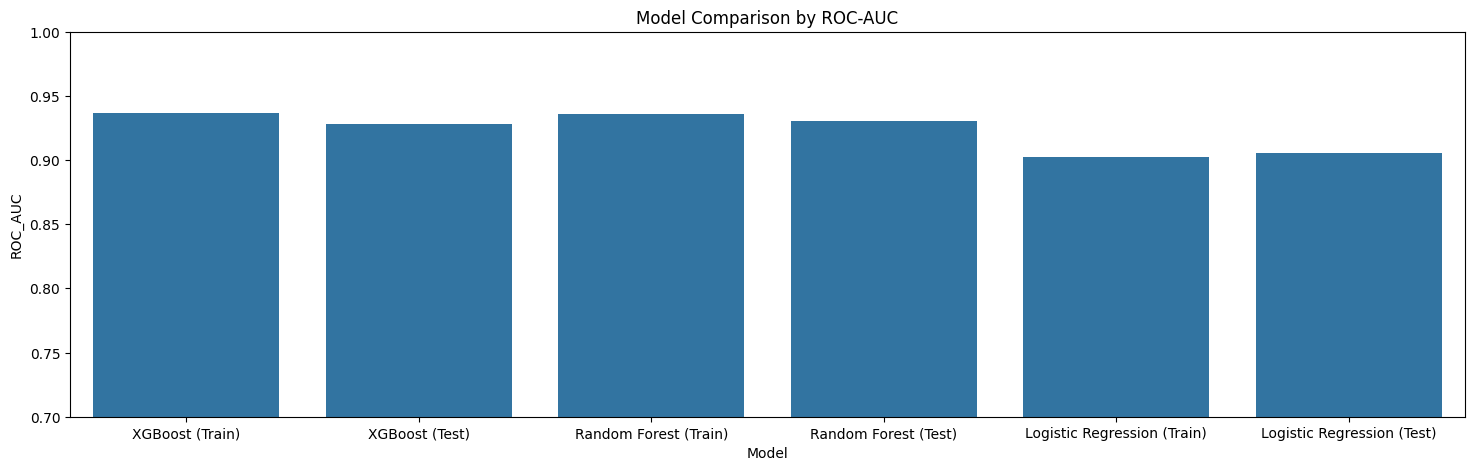

In [45]:
plt.figure(figsize=(18,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC_AUC"
)

plt.title("Model Comparison by ROC-AUC")
plt.ylim(0.7, 1.0)
plt.show()

# Feature Importance (XGBoost)

In [49]:
# Extract the trained XGBoost model from the pipeline
xgb_model = best_xgb.named_steps["model"]

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": x.columns,   # or x_train.columns
    "Importance": xgb_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 features
feature_importance.head(10)

,Feature,Importance
2,cp,0.270240
8,exang,0.203115
11,ca,0.088642
12,thal,0.066073
4,chol,0.065631
9,oldpeak,0.059929
1,sex,0.058830
5,fbs,0.039963
7,thalach,0.037769
10,slope,0.035293


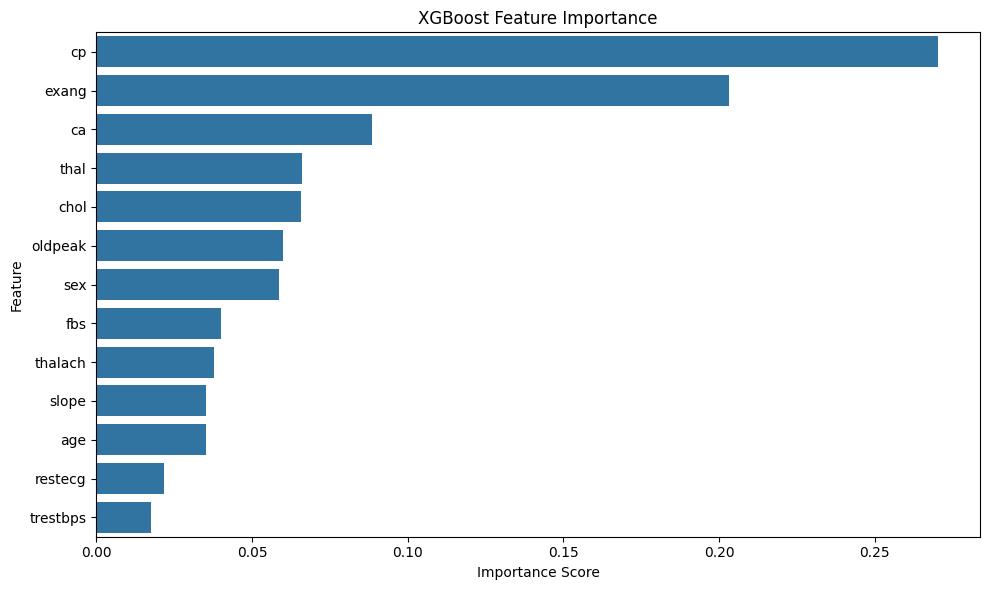

In [50]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

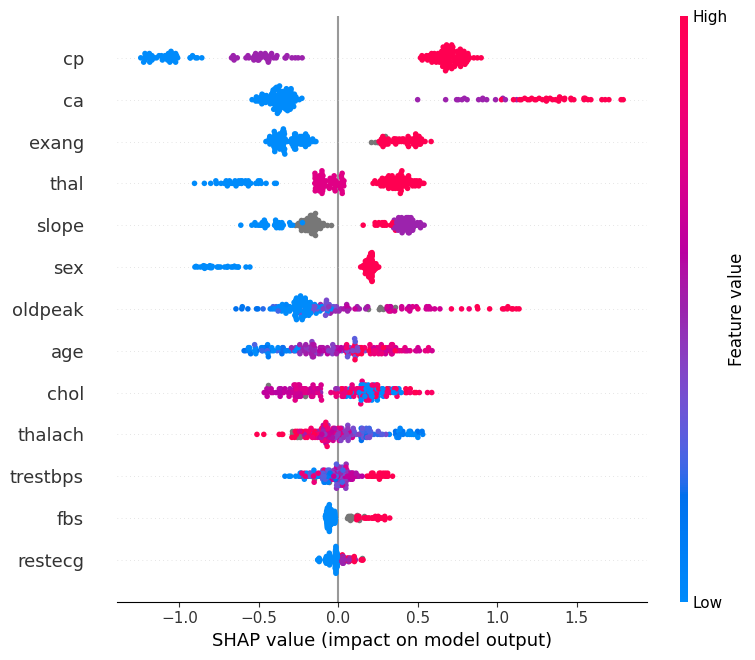

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(x_test)

shap.summary_plot(shap_values, x_test)

<Figure size 1000x800 with 0 Axes>

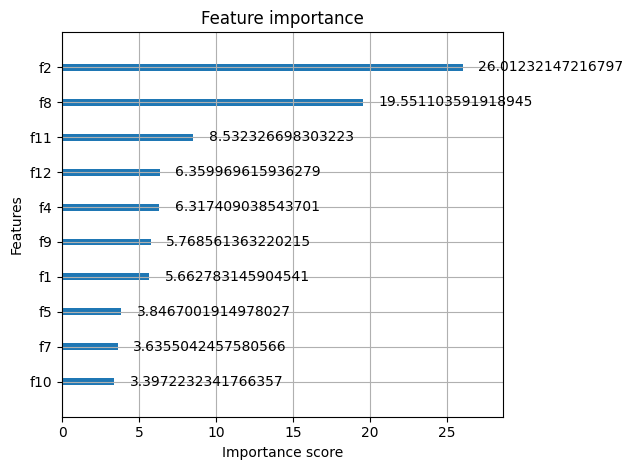

In [51]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_importance(
    best_xgb.named_steps["model"],
    max_num_features=10,
    importance_type="gain"   # or "weight", "cover"
)
plt.tight_layout()
plt.show()

# Save Result

In [52]:
results_df.to_csv(
    "results/centralized_results.csv",
    index=False
)

# Save Best Model

In [53]:
import joblib

joblib.dump(
    best_xgb,
    "models/xgboost_heart_disease.pkl"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


In [54]:
import os
print(os.path.exists("models/xgboost_heart_disease.pkl"))

True


In [ ]:
# Load the model later
# import joblib

# xgb_model = joblib.load("models/xgboost_heart_disease.pkl")
# print(xgb_model)

# scaler = joblib.load("models/scaler.pkl")
# xgb_model = joblib.load("models/xgboost_heart_disease.pkl")

In [55]:
print(xgb_search.best_params_)

{'model__subsample': 1.0, 'model__reg_lambda': 1.5, 'model__reg_alpha': 0, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.02, 'model__gamma': 0.3, 'model__colsample_bytree': 0.9}


# compairation

In [56]:
from sklearn.metrics import classification_report

print("="*50)
print(" EVALUATION REPORT: LOGISTIC REGRESSION ")
print("="*50)

# Generate predictions
y_pred_lr = best_lr.predict(x_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

 EVALUATION REPORT: LOGISTIC REGRESSION 

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83        82
           1       0.89      0.81      0.85       102

    accuracy                           0.84       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.84      0.84       184



In [ ]:
from sklearn.metrics import classification_report

print("="*50)
print(" EVALUATION REPORT: RANDOM FOREST ")
print("="*50)

# Generate predictions
y_pred_rf = best_rf.predict(x_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

 EVALUATION REPORT: RANDOM FOREST 

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        82
           1       0.86      0.87      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



In [57]:
from sklearn.metrics import classification_report

print("="*50)
print(" EVALUATION REPORT: XGBOOST ")
print("="*50)

# Generate predictions (safely accounting for feature alignment matrices)
try:
    y_pred_xgb = best_xgb.predict(x_test)
except ValueError:
    y_pred_xgb = best_xgb.predict(x_test.values)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

 EVALUATION REPORT: XGBOOST 

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        82
           1       0.89      0.83      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



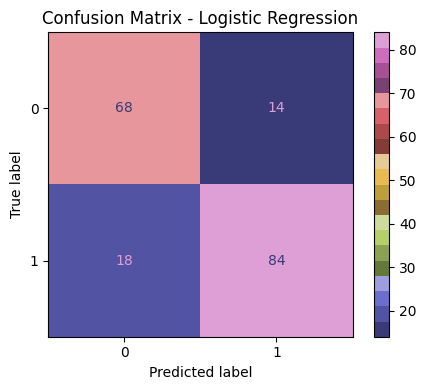

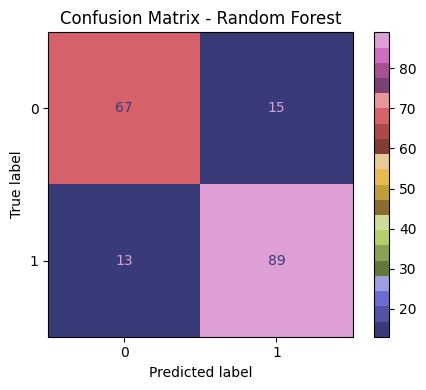

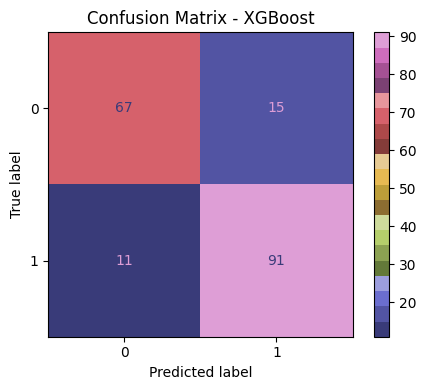

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

models = [
    (best_lr, "Logistic Regression"),
    (best_rf, "Random Forest"),
    (best_xgb, "XGBoost")
]

for model, name in models:
    fig, ax = plt.subplots(figsize=(5, 4))
    
    # Generate predictions and display matrix
    y_pred = model.predict(x_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        cmap='tab20b', 
        ax=ax
    )
    
    ax.set_title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

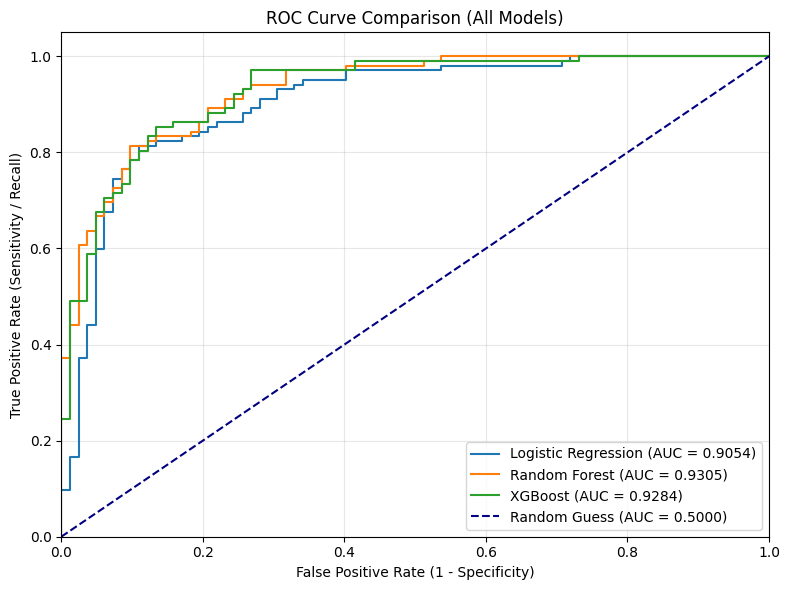

In [58]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

models = [
    (best_lr, "Logistic Regression"),
    (best_rf, "Random Forest"),
    (best_xgb, "XGBoost")
]

# Set up the combined plot canvas
plt.figure(figsize=(8, 6))

for model, name in models:
    # Get prediction probabilities for the positive class (column 1)
    y_prob = model.predict_proba(x_test)[:, 1]
    
    # Compute true positive rate and false positive rate
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Plot this model's curve onto the graph
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

# Final plot formatting adjustments
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guess (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve Comparison (All Models)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("="*60)
print(" LOGISTIC REGRESSION BEST PARAMETERS ")
print("="*60)
# Since lr is a pipeline, look inside the model step
try:
    print(best_lr.named_steps['model'].get_params())
except AttributeError:
    print(best_lr.get_params())

print("\n" + "="*60)
print(" RANDOM FOREST BEST PARAMETERS ")
print("="*60)
try:
    print(best_rf.get_params())
except NameError:
    print("best_rf is not defined in this session.")

print("\n" + "="*60)
print(" XGBOOST BEST PARAMETERS ")
print("="*60)
try:
    print(best_xgb.get_params())
except NameError:
    print("best_xgb is not defined in this session.")

 LOGISTIC REGRESSION BEST PARAMETERS 
{'C': 0.1, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': None, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

 RANDOM FOREST BEST PARAMETERS 
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

 XGBOOST BEST PARAMETERS 
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None,

In [59]:
import json
with open("models/xgboost_best_params.json", "w") as f:
    json.dump(xgb_search.best_params_, f, indent=4)

In [60]:
# import joblib
# import os
# os.makedirs("models", exist_ok=True)
# # Save all three models (pipelines include imputer/scaler automatically)
joblib.dump(best_lr,  "models/logistic_regression.pkl")
joblib.dump(best_rf,  "models/random_forest.pkl")
joblib.dump(best_xgb, "models/xgboost.pkl")
print("All models saved successfully.")

# import joblib

# # Load — everything (imputer, scaler, model) is restored in one line
# best_lr  = joblib.load("models/logistic_regression.pkl")
# best_rf  = joblib.load("models/random_forest.pkl")
# best_xgb = joblib.load("models/xgboost.pkl")

# # Predict directly on raw data — pipeline handles preprocessing
# y_pred = best_lr.predict(x_test)
# y_prob = best_lr.predict_proba(x_test)[:, 1]

All models saved successfully.
